In [4]:
import torch
import sys
sys.path.append('..')
from lightning_module import *
import matplotlib.pyplot as plt

In [8]:
# Load model from checkpoint
model = LOfTransformer.load_from_checkpoint('../../model_checkpoints/test_add_ons/epoch=20-val_loss=0.5798.ckpt')

Batch normalization disabled in embeddings!


In [10]:
# Load data module
d_module_reco = LOfData(
    source_file='../../data/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_train_Mar1023.root',
    target_file='../../data/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_train_Mar1023.root',
    batch_size=1,
    load_all=True,
    testing=False,
    use_truth=False
)


We have a fraction 0.8144455536320278 of good events in this file
/Users/kevingreif/anaconda3/envs/zjets/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:245: RuntimeWarning: invalid value encountered in log
  return impl(*broadcasted_args, **(kwargs or {}))
We have a fraction 0.8144455536320278 of good events in this file
We have 1160150 source events and 1160150 target events
We have 2320300 events in total


In [12]:
loader = iter(d_module_reco.predict_dataloader())

In [28]:
# Get the first event
kinematics, _, mask, _, _ = next(loader)

In [29]:
# Repeat event 200 times along first axis
kinematics = torch.tile(kinematics, (200, 1, 1))
mask = torch.tile(mask, (200, 1, 1))

In [30]:
# Now shift the phi coordinate of the leading muon
mphi = kinematics[:,2,0]
mphi_shift = torch.linspace(-np.pi, np.pi, 200) 
new_phi = mphi + mphi_shift
new_phi[new_phi > np.pi] -= 2*np.pi
new_phi[new_phi < -np.pi] += 2*np.pi
kinematics[:,2,0] = new_phi

In [31]:
mpt = kinematics[:,0,0]
kinematics[:,3,0] = mpt * torch.cos(new_phi)
kinematics[:,4,0] = mpt * torch.sin(new_phi)
kinematics[:,6,0] = torch.cos(new_phi)
kinematics[:,7,0] = torch.sin(new_phi) 

In [32]:
# Run inference with the shifted phis
model.eval()
with torch.no_grad():
    result = model(kinematics, mask)

In [33]:
# Make a plot of network output versus the leading muon phi
new_phi, ind = torch.sort(new_phi)
m1_phi = new_phi.numpy()
result = result[ind]
res = result.numpy()

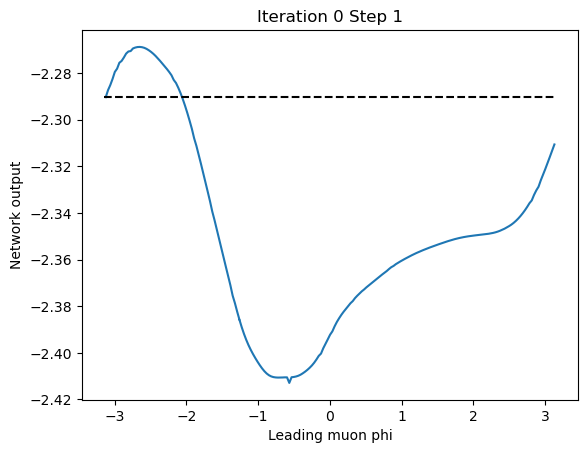

In [34]:
plt.plot(m1_phi, res)
plt.hlines(res[0], -np.pi, np.pi, linestyles='dashed', color='black')
plt.ylabel('Network output')
plt.xlabel('Leading muon phi')
plt.title('Iteration 0 Step 1')
plt.show()
